# Checking time of metrics

In [ ]:
# Импорт библиотек
import os, sys
import argparse
import pandas as pd
from tqdm.auto import tqdm
from evaluate import load
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

c:\HSE\project_poetry_2\ProjectPoetryRL\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bertscore = load("bertscore")
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\')
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\prose-to-poetry')
sys.path.append('c:\\Program Files (x86)\\eSpeak\\command_line')

In [3]:
%cd c:\HSE\project_poetry_2\ProjectPoetryRL

c:\HSE\project_poetry_2\ProjectPoetryRL


c:\HSE\project_poetry_2\ProjectPoetryRL\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
from util import print_options
from metrics import check_meter, check_meter_fast
from rhyme_metric import check_rhyme_scheme, get_rhyme_score

In [6]:
def filter_lines(text):
    lines = []
    for line in text.split('\n'):
        line = line.strip()
        for ch in line:
            if ch.isalpha():
                lines.append(line)
                break
    return lines
    
def check_len(lines):
    if len(lines) == 4 or len(lines) == 8:
        return 1.
    return 0.

In [ ]:
from transformers import pipeline

# multilingual NLI модель
nli = pipeline(
    "text-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    return_all_scores=True,
    device=-1  # 0 для первого GPU, -1 для CPU
)

tokenizer_sent = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
model_sent = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

In [33]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)

def encode(texts, batch_size=8):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        encoded = tokenizer_sent(batch, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model_sent(**encoded)

        embeddings = mean_pooling(model_output, encoded['attention_mask'])
        embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings)

    return torch.cat(all_embeddings, dim=0)

def eval_metrics(df):
    outputs = df["output"].tolist()
    references = df["text"].tolist()

    times = {}

    # -------- len_score --------
    start = time.perf_counter()
    len_scores = []
    for output in df["output"]:
        lines = filter_lines(output)
        len_scores.append(check_len(lines))
    times["len_score"] = time.perf_counter() - start
    len_scores = np.array(len_scores)

    # -------- rhyme_score_old --------
    start = time.perf_counter()
    rhyme_scores = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        rhyme_scores.append(
            check_rhyme_scheme(lines, row["rhyme_scheme"])
        )
    times["rhyme_score"] = time.perf_counter() - start
    rhyme_scores = np.array(rhyme_scores)
    
    # -------- rhyme_score_new --------
    start = time.perf_counter()
    rhyme_scores_new = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        rhyme_scores_new.append(
            get_rhyme_score(lines, row["rhyme_scheme"])
        )
    times["rhyme_score_new"] = time.perf_counter() - start
    rhyme_scores_new = np.array(rhyme_scores_new)

    # -------- meter_score --------
    start = time.perf_counter()
    meter_scores = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        meter_scores.append(
            check_meter(lines, row["meter"])
        )
    times["meter_score"] = time.perf_counter() - start
    meter_scores = np.array(meter_scores)

    # -------- meter_score_fast --------
    start = time.perf_counter()
    meter_scores2 = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        meter_scores2.append(
            check_meter_fast(lines, row["meter"])
        )
    times["meter_score_fast"] = time.perf_counter() - start
    meter_scores2 = np.array(meter_scores2)

    
    # -------- BERTScore --------
    start = time.perf_counter()
    bertscore_ = bertscore.compute(
        predictions=outputs,
        references=references,
        lang="ru"
    )
    times["BERTscore"] = time.perf_counter() - start
    bert_scores = np.array(bertscore_["f1"])

    # -------- entailment --------
    start = time.perf_counter()
    batch_size = 8  # можно увеличивать, зависит от GPU
    entailment_scores = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_prose = df["text"].iloc[i:i+batch_size].tolist()
        batch_poem = df["output"].iloc[i:i+batch_size].tolist()

        # pipeline принимает словарь с текстами и текстами-парами
        batch_res = nli(
            [{"text": p, "text_pair": h} for p, h in zip(batch_prose, batch_poem)],
            top_k=None,
        )
        for res in batch_res:
            score = {r["label"]: r["score"] for r in res}
            entailment_scores.append(score.get("entailment", 0.0))
    times["entailment"] = time.perf_counter() - start
    entailment_scores = np.array(entailment_scores)

    # -------- cos sentense --------
    emb_prose = encode(references) # можно посчитать заранее поэтому не учитывается в подсчете времени
    start = time.perf_counter()
    emb_poem = encode(outputs)
    cos_sim = (emb_prose * emb_poem).sum(dim=1).cpu().numpy()
    times["semantic_embeddings"] = time.perf_counter() - start
    cos_sim = np.array(cos_sim)

    # -------- статистика --------
    metrics = {
        "BERTscore": bert_scores,
        "entailment": entailment_scores,
        "semantic_embeddings": cos_sim,
        "len_score": len_scores,
        "rhyme_score": rhyme_scores,
        "rhyme_score_new": rhyme_scores_new,
        "meter_score": meter_scores,
        "meter_score_fast": meter_scores2
    }

    stats = []
    for name, scores in metrics.items():
        stats.append({
            "metric": name,
            "mean": scores.mean(),
            "std": scores.std(),
            "time_sec": times[name] / len(df)
        })

    stats_df = pd.DataFrame(stats).set_index("metric")

    print("\nMetric statistics:")
    print(stats_df)

    return stats_df, metrics

def viz_metrics(metrics):
    # -------- распределения --------
    plt.figure(figsize=(15, 10))

    for i, (name, scores) in enumerate(metrics.items(), 1):
        plt.subplot(2, 4, i)
        plt.hist(scores, bins=30)
        plt.title(name)

    plt.tight_layout()
    plt.show()

    df_metrics = pd.DataFrame(metrics)
    corr = df_metrics.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Корреляция между метриками")
    plt.show()

In [11]:
test_dataset = 'dataset/prosa_test_text.csv'
input_file = 'output/qwen.csv'

inputs = pd.read_csv(test_dataset)
outputs = pd.read_csv(input_file)
df = pd.concat([inputs, outputs], axis=1).rename({'qwen': 'output'}, axis=1)

In [12]:
stats_df, metrics = eval_metrics(df)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1792.37it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 125/125 [01:45<00:00,  1.18it/s]


Metric statistics:
                         mean       std  time_sec
metric                                           
BERTscore            0.773638  0.073938  0.174479
entailment           0.536566  0.465434  4.026756
semantic_embeddings  0.839702  0.100604  0.105608
len_score            0.936000  0.244753  0.000002
rhyme_score          0.043525  0.147585  0.131897
rhyme_score_new      0.053884  0.144477  0.130758
meter_score          0.408922  0.109209  0.011529
meter_score_fast     0.239028  0.061778  0.005345


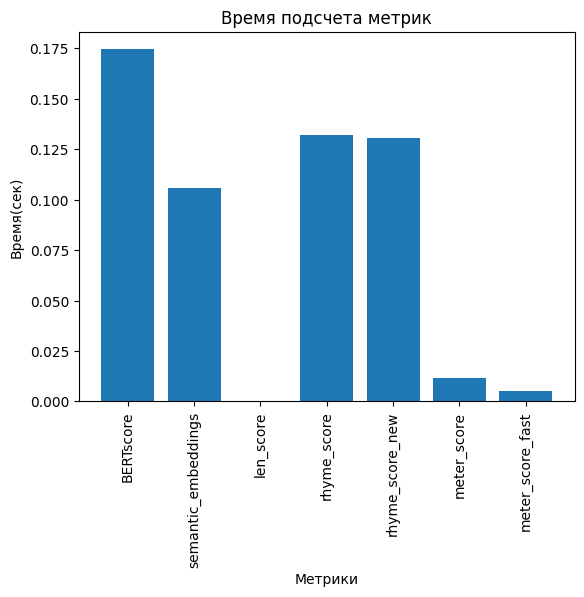

In [30]:
stats_df_ = stats_df.copy().drop('entailment')
plt.bar(stats_df_.index, stats_df_['time_sec'])

plt.xlabel("Метрики")
plt.ylabel("Время(сек)")
plt.title("Время подсчета метрик")
plt.xticks(rotation=90)
plt.show()

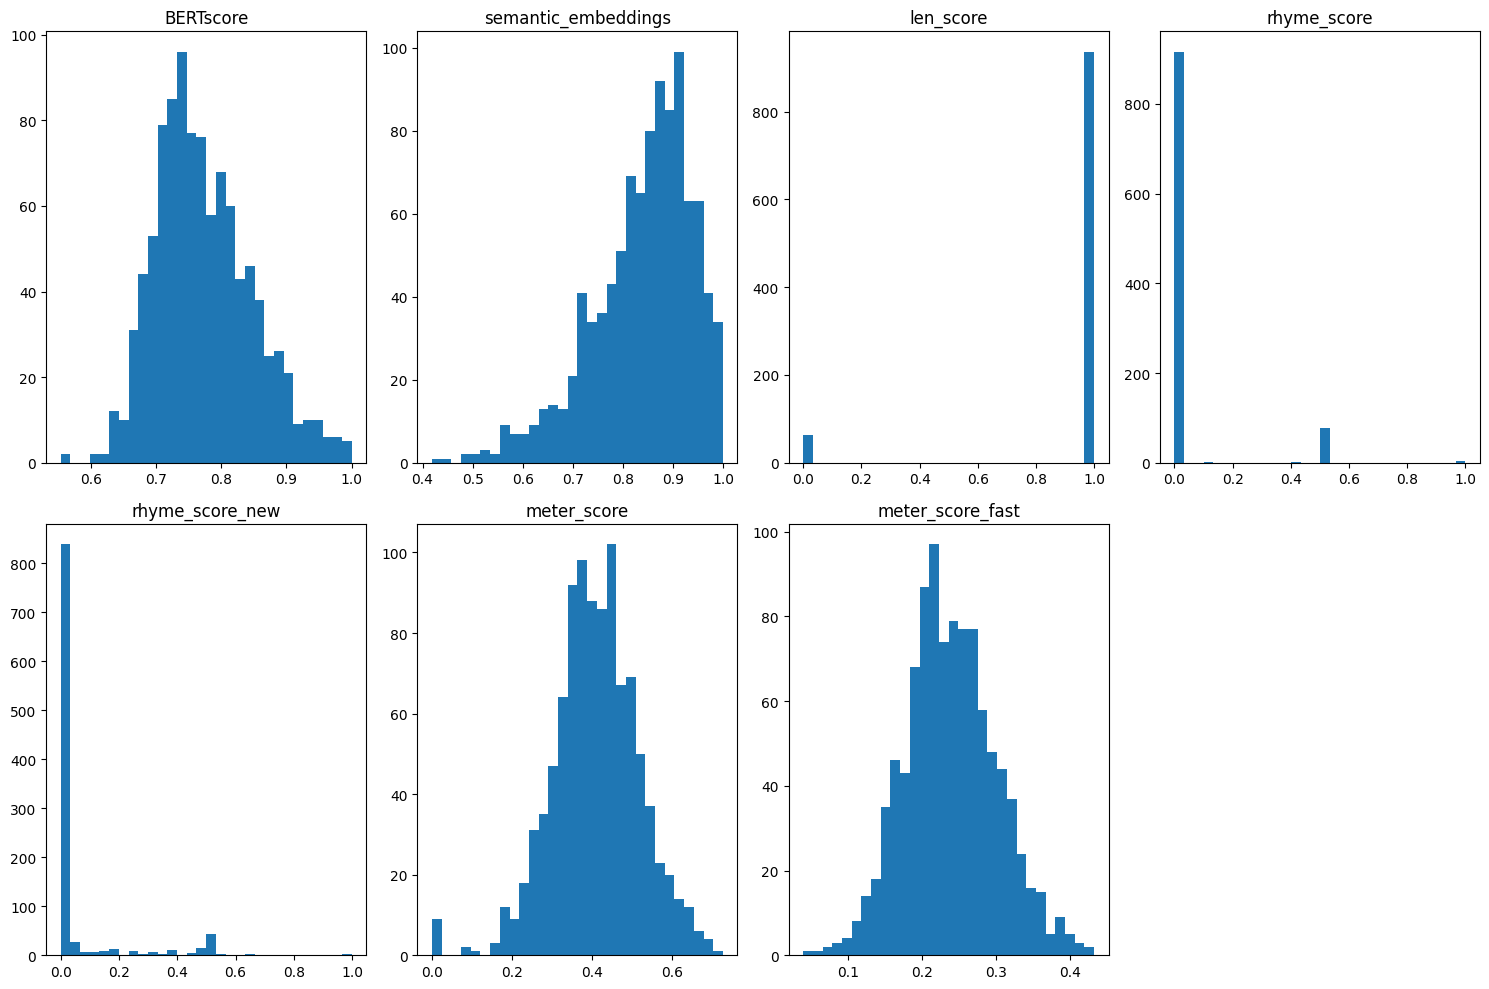

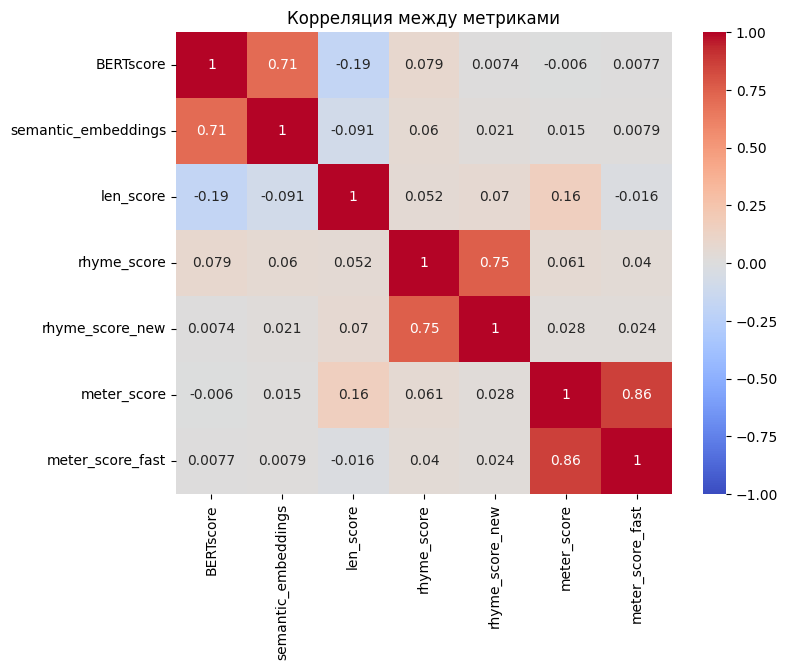

In [34]:
metrics_ = metrics.copy()
del metrics_['entailment']
viz_metrics(metrics_)

In [21]:
cosine = np.array(metrics["semantic_embeddings"])
bert = np.array(metrics["BERTscore"])

# разница
diff = cosine - bert

# индексы
top_cosine_idx = np.argsort(-diff)[:10]   # cosine сильно больше
top_bert_idx = np.argsort(diff)[:10]      # bertscore сильно больше

def print_examples(indices, title):
    print(f"\n{'='*20} {title} {'='*20}")
    for i in indices:
        print(f"\nIndex: {i}")
        print(f"Cosine: {cosine[i]:.4f} | BERTScore: {bert[i]:.4f} | Diff: {diff[i]:.4f}")
        print(f"\nSRC:\n{df['text'][i]}")
        print(f"\nGEN:\n{df['output'][i]}")
        print("-"*50)

# вывод
print_examples(top_cosine_idx, "Cosine >> BERTScore")
print_examples(top_bert_idx, "BERTScore >> Cosine")


==================== Cosine >> BERTScore ====================

Index: 951
Cosine: 0.8756 | BERTScore: 0.6431 | Diff: 0.2325

SRC:
Разоблаченные владыки мира не могут противопоставить наполеоновскому идеалу славы и величия, не имеющего смысла, никакого разумного идеала.


GEN:
Не владыки мирозданья силы,
Наполеона идеал не удержит,
Безумный стремленье славы путь
В безбрежье мглы непостижим.
--------------------------------------------------

Index: 397
Cosine: 0.9359 | BERTScore: 0.7053 | Diff: 0.2306

SRC:
Он молился, просил бога помочь ему, вселиться в него и очистить его, а между тем то, о чем он просил, уже совершилось.


GEN:
Молился он, бога молил,
Чтоб в душу его войти,
И очистить грехи свои,
А то, о чем молил, уже было.

Он молился, чтоб в себя войти,
Бога просил помочь,
Чтоб очистить сердце свое,
А то, о чем молил, уже было.
--------------------------------------------------

Index: 890
Cosine: 0.9116 | BERTScore: 0.6843 | Diff: 0.2273

SRC:
Она разливала чай – слушая неистощи